In [13]:
import pandas as pd
import numpy as np
import pickle
import os
from collections import defaultdict
from main import BenchmarkFilteringPipeline, BenchmarkDataLoader, group_responses_by_question


import sys
import os
import json
import logging
import argparse
import csv
import numpy as np
import pickle
import random
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from math import comb
from typing import Dict, List, Tuple
from collections import Counter
from datetime import datetime

from sentence_transformers import SentenceTransformer
import torch
from sklearn.manifold import TSNE

# Add src to path

from src.comprehensive_rule_filtering import ComprehensiveRuleFilter
from src.rule_filtering_orchestrator import RuleFilteringOrchestrator
from src.llm_judge_filtering import LLMJudge, LLMJudgeConfig, LLMJudgeStep
from src.data_loader import BenchmarkDataLoader
from src.diversity_greedy import maximize_diversity_greedy
from src.utils.types import (
    Benchmark,
    UniqueQuestionID,
    LLMJudgeOutput,
    PipelineOutput,
    RuleBasedOutput,
)
from src.utils import group_responses_by_question, log_confusion_matrix_human_labelled
from src.bench_loaders import get_bench_loader
from metric.irt_metric import compute_irt_metric


In [16]:
from src.utils.types import UniqueQuestionID, Benchmark
from typing import Dict, List, Tuple

def load_filtered_questions(csv_path):
    """Load filtered questions from CSV to see which passed each step."""
    df = pd.read_csv(csv_path)
    
    # Convert to UniqueQuestionID format
    from src.utils.types import UniqueQuestionID, Benchmark
    
    filtered_questions = {}
    for _, row in df.iterrows():
        qid = UniqueQuestionID(
            benchmark=Benchmark(row['Benchmark']),
            task_name=row['task_type'] if pd.notna(row['task_type']) else None,
            question_id=row['task_id']
        )
        
        # Track which steps passed
        filtered_questions[qid] = {
            'specific_rule_passed': row.get('specific_rule_passed', False),
            'specific_llm_passed': row.get('specific_llm_passed', False),
            'comp_passed': row.get('comp_passed', False),
        }
    
    return filtered_questions
def _load_precomputed_results(csv_path: str) -> Dict[UniqueQuestionID, Dict]:
        """Load precomputed filtering results from CSV and convert to dict keyed by UniqueQuestionID."""
        precomputed_results = {}

        with open(csv_path, "r", encoding="utf-8") as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                # Create UniqueQuestionID from CSV columns
                unique_question_id = UniqueQuestionID(
                    benchmark=row["Benchmark"],
                    task_name=row["task_type"] if row["task_type"] else None,
                    question_id=row["task_id"],
                )

                # Convert string values to appropriate types, empty strings to None
                results = {}
                for key, value in row.items():
                    if key in ["Benchmark", "task_type", "task_id"]:
                        continue  # Skip keys used for UniqueQuestionID

                    if value == "" or value is None:
                        results[key] = None
                    elif value.lower() in ["true", "false"]:
                        results[key] = value.lower() == "true"
                    else:
                        results[key] = value

                precomputed_results[unique_question_id] = results

        return precomputed_results


def load_benchmark_data(target_benchmark):
    """Load benchmark data using the pipeline's data loader."""
    data_loader = BenchmarkDataLoader()
    all_responses = data_loader.load_benchmark_data("benchmark", [target_benchmark])
    return group_responses_by_question(all_responses)

def load_embeddings(benchmark_name, no_system_prompt=False):
    """Load precomputed embeddings."""
    if no_system_prompt:
        embed_file = f"./{benchmark_name}_embed_dict_only_instruction.pkl"
    else:
        embed_file = f"./{benchmark_name}_embed_dict.pkl"
    
    if os.path.exists(embed_file):
        with open(embed_file, "rb") as f:
            return pickle.load(f)
    else:
        print(f"Embedding file {embed_file} not found!")
        return None

In [76]:
def compute_task_wise_metrics(responses_by_question, embeddings_dict, step_name="all") -> Dict[UniqueQuestionID, Dict]:
    """Compute task-wise metrics using the same logic as the pipeline.
    
    Returns:
        Dict[UniqueQuestionID, Dict]: Dictionary mapping question IDs to their metrics
    """
    
    task_stats = {}
    question_ids = list(responses_by_question.keys())
    
    # Compute pairwise cosine distances between all tasks
    all_embeddings = np.array([embeddings_dict[qid] for qid in question_ids])
    cosine_sim_matrix = np.matmul(all_embeddings, all_embeddings.T)
    cosine_dist_matrix = 1 - cosine_sim_matrix
    
    # Create mapping from question_id to index
    qid_to_idx = {qid: idx for idx, qid in enumerate(question_ids)}
    
    # For each task, compute statistics
    for question_id in question_ids:
        task_idx = qid_to_idx[question_id]
        responses = responses_by_question[question_id]
        
        # 1. Compute diversity: average cosine distance to all other tasks
        distances_to_other_tasks = [
            cosine_dist_matrix[task_idx, other_idx]
            for other_idx in range(len(question_ids))
            if other_idx != task_idx
        ]
        avg_dist = np.mean(distances_to_other_tasks) if distances_to_other_tasks else 0.0
        
        # 2. Compute model agreement and correct ratio
        model_scores = {}
        for response in responses:
            model_name = response["model_path"]
            score = response["eval_result"]["score"]
            model_scores[model_name] = score
        
        # Compute model correct ratio
        binary_scores = [1 if score > 0.5 else 0 for score in model_scores.values()]
        model_correct_ratio = np.mean(binary_scores) if binary_scores else 0.0
        
        # Compute model agreement (average pairwise agreement for this task)
        model_names = list(model_scores.keys())
        if len(model_names) < 2:
            model_agreement = 1.0  # Perfect agreement if only one model
        else:
            agreements = 0
            total_pairs = 0
            
            for i, model1 in enumerate(model_names):
                for j, model2 in enumerate(model_names):
                    if i < j:  # Only count each pair once
                        score1 = model_scores[model1]
                        score2 = model_scores[model2]
                        
                        # Binary correctness
                        correct1 = 1 if score1 > 0.5 else 0
                        correct2 = 1 if score2 > 0.5 else 0
                        
                        # Agreement if both correct or both incorrect
                        if correct1 == correct2:
                            agreements += 1
                        total_pairs += 1
            
            model_agreement = agreements / total_pairs if total_pairs > 0 else 0.0
        
        # Extract additional info
        benchmark_name = question_id.benchmark.value if hasattr(question_id.benchmark, 'value') else str(question_id.benchmark)
        task_name = question_id.task_name if question_id.task_name else ""
        task_id = question_id.question_id
        
        # Compute mean and variance of scores for this task
        scores = list(model_scores.values())
        mean_score = np.mean(scores) if scores else 0.0
        var_score = np.var(scores) if len(scores) > 1 else 0.0
        
        # Store metrics in dictionary with UniqueQuestionID as key
        task_stats[question_id] = {
            "benchmark": benchmark_name,
            "task_name": task_name,
            "task_id": task_id,
            "avg_dist": float(avg_dist),
            "model_agreement": float(model_agreement),
            "model_correct_ratio": float(model_correct_ratio),
            "mean_score": float(mean_score),
            "var_score": float(var_score),
            "num_models": len(model_scores),
            "step": step_name
        }
    
    return task_stats, cosine_dist_matrix

In [ ]:
####### Parameters #######

target_benchmark = "tau-bench"
csv_path = "./pipeline_results/ref_tau-bench_20251024_085713_filtering_summary.csv"
no_system_prompt = True  # Set to True if you used --no-system-prompt


In [52]:
# results, filtered_questions = analyze_filtering_impact(
#     target_benchmark, csv_path, no_system_prompt
# )
print("Loading filtered questions...")
filtered_questions = _load_precomputed_results(csv_path)

print("Loading benchmark data...")
responses_by_question = load_benchmark_data(target_benchmark)

print("Loading embeddings...")
embeddings_dict = load_embeddings(target_benchmark, no_system_prompt)
# if embeddings_dict is None:
#     return None, None

# Compute metrics for different filtering steps
results = {}

# Original dataset (all questions)
print("Computing metrics for original dataset...")
original_stats, original_dist_matrix = compute_task_wise_metrics(
    responses_by_question, embeddings_dict, "original"
)
results["original"] = {
    "stats": original_stats,
    "dist_matrix": original_dist_matrix
}


Loading filtered questions...
Loading benchmark data...
Loading embeddings...
Computing metrics for original dataset...


In [69]:
def _compute_diversity(
        self, question_ids: set
    ) -> Dict[str, float]:
        """Compute semantic diversity for each benchmark using average pairwise cosine distance.

        Uses pre-computed embeddings for efficiency.
        The metric is bounded in [0, 1] per the expression: (2 / (N * (N - 1))) * sum{i<j} [1 - cos(e_i, e_j)]
        where N is the number of samples and cos(·,·) is cosine similarity.

        Args:
            question_ids: Set of question IDs to compute diversity for
        """
        diversity_dict: Dict[str, float] = {}

        for benchmark_name in self.all_questions:
                # Get pre-computed embeddings for these questions
            embeddings = np.array([self.embeddings_dict[qid] for qid in question_ids if qid.benchmark.value == benchmark_name])

            # Cosine similarity matrix via dot product because embeddings are normalised
            sim_matrix = np.matmul(embeddings, embeddings.T)

            # Extract upper triangle (i < j)
            triu_indices = np.triu_indices(len(embeddings), k=1)
            cosine_sims = sim_matrix[triu_indices]
            avg_distance = np.mean(1 - cosine_sims)

            diversity_dict[benchmark_name] = float(avg_distance)

        return diversity_dict

In [70]:
original_dist_matrix
# Get filtered / non filtered qids

array([[-9.766e-04,  4.033e-01,  3.721e-01, ...,  5.029e-01,  5.586e-01,
         5.840e-01],
       [ 4.033e-01,  0.000e+00,  3.008e-01, ...,  4.580e-01,  4.717e-01,
         5.278e-01],
       [ 3.721e-01,  3.008e-01,  0.000e+00, ...,  4.595e-01,  4.800e-01,
         4.951e-01],
       ...,
       [ 5.029e-01,  4.580e-01,  4.595e-01, ...,  0.000e+00,  5.957e-02,
         3.667e-01],
       [ 5.586e-01,  4.717e-01,  4.800e-01, ...,  5.957e-02,  4.883e-04,
         3.027e-01],
       [ 5.840e-01,  5.278e-01,  4.951e-01, ...,  3.667e-01,  3.027e-01,
         4.883e-04]], dtype=float16)

In [71]:
# Get filtered / non filtered qids
issue_qids = []
non_issue_qids = []
for qid in filtered_questions:
    # print(filtered_questions[qid])
    
    if filtered_questions[qid]['specific_rule_passed']==True and filtered_questions[qid]['specific_llm_passed']==True:
        non_issue_qids.append(qid)
    else:
        issue_qids.append(qid)

print(len(issue_qids), len(non_issue_qids), len(filtered_questions))


42 123 165


In [72]:
# Sample structure of original_stats[qid]
original_stats[qid]

{'benchmark': 'tau-bench',
 'task_name': 'airline',
 'task_id': 'airline_12',
 'avg_diversity': 0.444580078125,
 'model_agreement': 0.7915966386554621,
 'model_correct_ratio': 0.8857142857142857,
 'mean_score': 0.8857142857142857,
 'var_score': 0.1012244897959184,
 'num_models': 35,
 'step': 'original'}

In [ ]:
# Get the stats of filtered vs non filtered qids
# map the qids to idx for simple handling

# issue_idx = np.zeros(len(original_stats.keys()))
issue_idx = []
stats = {}
stats['avg_diversity'] = np.zeros(len(original_stats.keys()))
stats['model_agreement'] = np.zeros(len(original_stats.keys()))
stats['model_correct_ratio'] = np.zeros(len(original_stats.keys()))


for i,qid in enumerate(original_stats.keys()):
    if qid in issue_qids:
        # stats['issue_idx'][i] = 1
        issue_idx.append(int(i))
    stats['avg_diversity'][i] = original_stats[qid]['avg_diversity']
    stats['model_agreement'][i] = original_stats[qid]['model_agreement']
    stats['model_correct_ratio'][i] = original_stats[qid]['model_correct_ratio']
    
non_issue_idx = [i for i in range(len(original_stats.keys())) if i not in issue_idx]


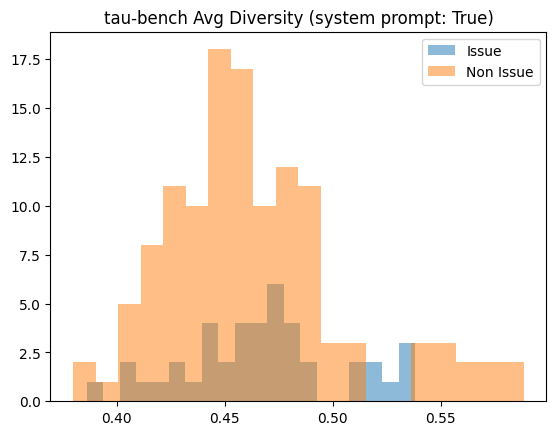

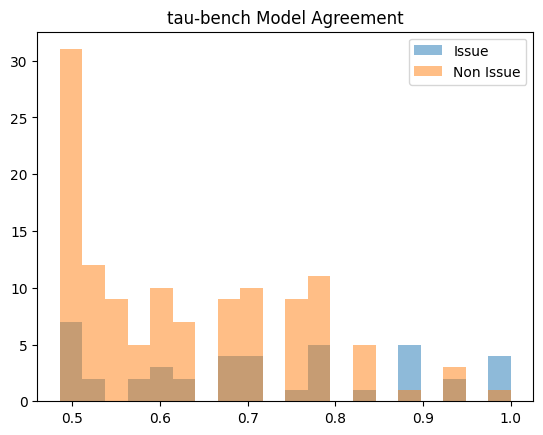

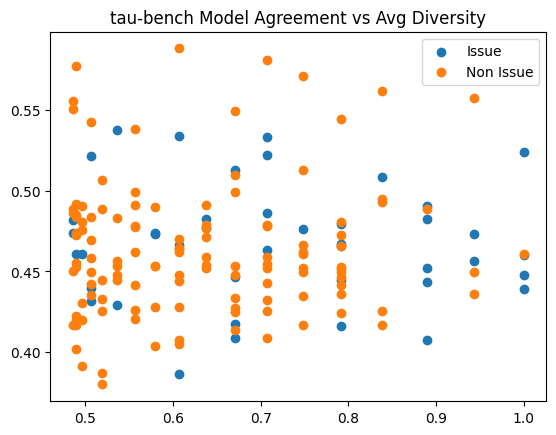

In [75]:
plt.hist(stats['avg_diversity'][issue_idx], bins=20, alpha=0.5, label='Issue')
plt.hist(stats['avg_diversity'][non_issue_idx], bins=20, alpha=0.5, label='Non Issue')
plt.legend()
plt.title(f'{target_benchmark} Avg Diversity (system prompt: {no_system_prompt})')
plt.show()
plt.hist(stats['model_agreement'][issue_idx], bins=20, alpha=0.5, label='Issue')
plt.hist(stats['model_agreement'][non_issue_idx], bins=20, alpha=0.5, label='Non Issue')
plt.legend()
plt.title(f'{target_benchmark} Model Agreement')
plt.show()

plt.scatter(stats['model_agreement'][issue_idx], stats['avg_diversity'][issue_idx], label='Issue')
plt.scatter(stats['model_agreement'][non_issue_idx], stats['avg_diversity'][non_issue_idx], label='Non Issue')
plt.legend()
plt.title(f'{target_benchmark} Model Agreement vs Avg Diversity')
plt.show()

In [ ]:
# filter out low diversity & high agreement


In [ ]:
def _compute_diversity()

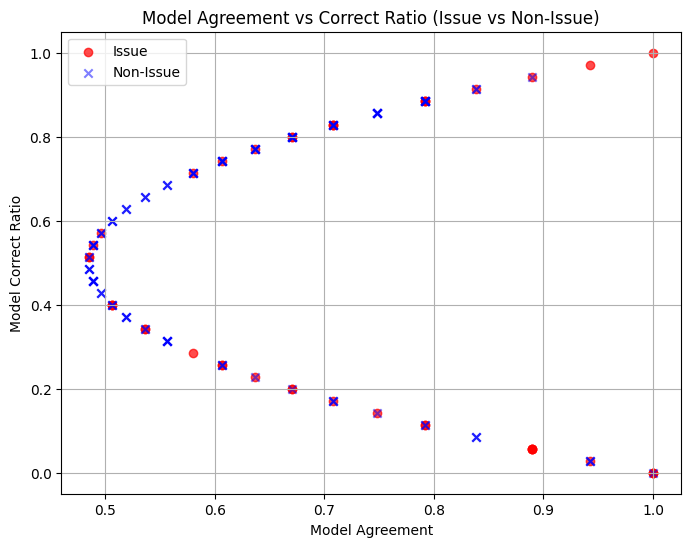

In [60]:
# Plot issue and non-issue points in different colors on a scatterplot
plt.figure(figsize=(8,6))
plt.scatter(
    stats['model_agreement'][issue_idx],
    stats['model_correct_ratio'][issue_idx],
    color='red', label='Issue', alpha=0.7, marker='o'
)
plt.scatter(
    stats['model_agreement'][non_issue_idx],
    stats['model_correct_ratio'][non_issue_idx],
    color='blue', label='Non-Issue', alpha=0.5, marker='x'
)
plt.xlabel('Model Agreement')
plt.ylabel('Model Correct Ratio')
plt.legend()
plt.title('Model Agreement vs Correct Ratio (Issue vs Non-Issue)')
plt.grid(True)
plt.show()


In [ ]:
plt.hist(stats['model_agreement'][issue_idx],)

In [ ]:
stats['avg_diversity'][issue_idx]
stats['model_agreement'][issue_idx]
stats['model_correct_ratio'][issue_idx]

stats['avg_diversity'][non_issue_idx]
stats['model_agreement'][non_issue_idx]
stats['model_correct_ratio'][non_issue_idx]

array([0.4       , 0.4       , 0.34285714, 0.4       , 0.54285714,
       0.05714286, 0.88571429, 0.51428571, 0.34285714, 0.22857143,
       0.88571429, 0.        , 0.05714286, 0.05714286, 0.71428571,
       0.        , 0.14285714, 0.17142857, 0.28571429, 0.11428571,
       0.77142857, 0.74285714, 0.82857143, 0.97142857, 0.88571429,
       0.2       , 0.02857143, 0.91428571, 0.57142857, 0.8       ,
       0.8       , 0.82857143, 0.25714286, 0.82857143, 1.        ,
       0.51428571, 0.94285714, 0.25714286, 0.05714286, 0.2       ,
       0.        , 0.11428571])

In [ ]:
# ---- Group tasks by filtering results and analyze metrics (Step 1 & 2 only) ----
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np

def group_tasks_by_filtering_status(original_stats, filtered_questions):
    """Group tasks by their filtering status and extract metrics."""
    
    # Group tasks by filtering status
    groups = {
        'passed_all': [],      # Passed both step 1 and step 2
        'failed_step1': [],    # Failed at step 1 (rule-based)
        'failed_step2': [],    # Passed step 1, failed step 2 (LLM)
    }
    
    for qid, stats in original_stats.items():
        filter_entry = filtered_questions.get(qid, {})
        
        # Determine filtering status
        step1_passed = filter_entry.get('specific_rule_passed', False)
        step2_passed = filter_entry.get('specific_llm_passed', False)
        
        # Add task info with metrics
        task_info = {
            'qid': qid,
            'benchmark': stats['benchmark'],
            'task_name': stats['task_name'],
            'task_id': stats['task_id'],
            'model_agreement': stats['model_agreement'],
            'avg_diversity': stats['avg_diversity'],
            'model_correct_ratio': stats['model_correct_ratio'],
            'mean_score': stats['mean_score'],
            'var_score': stats['var_score'],
            'num_models': stats['num_models'],
            'step1_passed': step1_passed,
            'step2_passed': step2_passed,
        }
        
        # Categorize based on filtering status
        if step1_passed and step2_passed:
            groups['passed_all'].append(task_info)
        elif not step1_passed:
            groups['failed_step1'].append(task_info)
        elif step1_passed and not step2_passed:
            groups['failed_step2'].append(task_info)
    
    return groups

def analyze_group_metrics(groups):
    """Analyze metrics for each group."""
    analysis = {}
    
    for group_name, tasks in groups.items():
        if not tasks:
            analysis[group_name] = {
                'count': 0,
                'metrics': {}
            }
            continue
            
        # Extract metrics as numpy arrays
        agreements = np.array([t['model_agreement'] for t in tasks])
        diversities = np.array([t['avg_diversity'] for t in tasks])
        correct_ratios = np.array([t['model_correct_ratio'] for t in tasks])
        mean_scores = np.array([t['mean_score'] for t in tasks])
        var_scores = np.array([t['var_score'] for t in tasks])
        
        # Calculate statistics
        analysis[group_name] = {
            'count': len(tasks),
            'tasks': tasks,
            'metrics': {
                'agreement': {
                    'mean': np.mean(agreements),
                    'std': np.std(agreements),
                    'min': np.min(agreements),
                    'max': np.max(agreements),
                    'median': np.median(agreements)
                },
                'diversity': {
                    'mean': np.mean(diversities),
                    'std': np.std(diversities),
                    'min': np.min(diversities),
                    'max': np.max(diversities),
                    'median': np.median(diversities)
                },
                'correct_ratio': {
                    'mean': np.mean(correct_ratios),
                    'std': np.std(correct_ratios),
                    'min': np.min(correct_ratios),
                    'max': np.max(correct_ratios),
                    'median': np.median(correct_ratios)
                },
                'mean_score': {
                    'mean': np.mean(mean_scores),
                    'std': np.std(mean_scores),
                    'min': np.min(mean_scores),
                    'max': np.max(mean_scores),
                    'median': np.median(mean_scores)
                },
                'var_score': {
                    'mean': np.mean(var_scores),
                    'std': np.std(var_scores),
                    'min': np.min(var_scores),
                    'max': np.max(var_scores),
                    'median': np.median(var_scores)
                }
            }
        }
    
    return analysis

# Group tasks by filtering status
print("Grouping tasks by filtering status (Step 1 & 2 only)...")
groups = group_tasks_by_filtering_status(original_stats, filtered_questions)

# Print group counts
print("\nFiltering Status Groups:")
for group_name, tasks in groups.items():
    print(f"  {group_name}: {len(tasks)} tasks")

# Analyze metrics for each group
print("\nAnalyzing group metrics...")
analysis = analyze_group_metrics(groups)

# Print summary statistics
print("\nGroup Metrics Summary:")
for group_name, data in analysis.items():
    if data['count'] == 0:
        continue
    print(f"\n{group_name.upper()} ({data['count']} tasks):")
    metrics = data['metrics']
    print(f"  Agreement: {metrics['agreement']['mean']:.3f} ± {metrics['agreement']['std']:.3f}")
    print(f"  Diversity: {metrics['diversity']['mean']:.3f} ± {metrics['diversity']['std']:.3f}")
    print(f"  Correct Ratio: {metrics['correct_ratio']['mean']:.3f} ± {metrics['correct_ratio']['std']:.3f}")
    print(f"  Mean Score: {metrics['mean_score']['mean']:.3f} ± {metrics['mean_score']['std']:.3f}")
    print(f"  Score Variance: {metrics['var_score']['mean']:.3f} ± {metrics['var_score']['std']:.3f}")


Grouping tasks by filtering status (Step 1 & 2 only)...


AttributeError: 'list' object has no attribute 'items'

In [ ]:
filter_entry = filtered_questions.get(qid, {})

# Determine filtering status
step1_passed = filter_entry.get('specific_rule_passed', False)
step2_passed = filter_entry.get('specific_llm_passed', False)
original_stats

[{'benchmark': 'tau-bench',
  'task_name': 'airline',
  'task_id': 'airline_0',
  'avg_diversity': 0.283203125,
  'model_agreement': 0.5058823529411764,
  'model_correct_ratio': 0.4,
  'mean_score': 0.4,
  'var_score': 0.24000000000000002,
  'num_models': 35,
  'step': 'original'},
 {'benchmark': 'tau-bench',
  'task_name': 'airline',
  'task_id': 'airline_1',
  'avg_diversity': 0.28076171875,
  'model_agreement': 0.6067226890756302,
  'model_correct_ratio': 0.7428571428571429,
  'mean_score': 0.7428571428571429,
  'var_score': 0.19102040816326538,
  'num_models': 35,
  'step': 'original'},
 {'benchmark': 'tau-bench',
  'task_name': 'airline',
  'task_id': 'airline_2',
  'avg_diversity': 0.28857421875,
  'model_agreement': 0.5361344537815126,
  'model_correct_ratio': 0.34285714285714286,
  'mean_score': 0.34285714285714286,
  'var_score': 0.2253061224489796,
  'num_models': 35,
  'step': 'original'},
 {'benchmark': 'tau-bench',
  'task_name': 'airline',
  'task_id': 'airline_3',
  'avg

In [ ]:
# ---- Visualization Functions (Step 1 & 2 only) ----
def create_metric_comparison_plots(analysis):
    """Create comparison plots for different metrics across groups."""
    
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Prepare data for plotting
    plot_data = []
    for group_name, data in analysis.items():
        if data['count'] == 0:
            continue
        for task in data['tasks']:
            plot_data.append({
                'Group': group_name.replace('_', ' ').title(),
                'Agreement': task['model_agreement'],
                'Diversity': task['avg_diversity'],
                'Correct Ratio': task['model_correct_ratio'],
                'Mean Score': task['mean_score'],
                'Score Variance': task['var_score'],
                'Task ID': f"{task['task_name']}_{task['task_id']}"
            })
    
    df = pd.DataFrame(plot_data)
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Task Metrics by Filtering Status (Step 1 & 2)', fontsize=16, fontweight='bold')
    
    # Plot 1: Agreement distribution
    sns.boxplot(data=df, x='Group', y='Agreement', ax=axes[0,0])
    axes[0,0].set_title('Model Agreement by Group')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Diversity distribution
    sns.boxplot(data=df, x='Group', y='Diversity', ax=axes[0,1])
    axes[0,1].set_title('Semantic Diversity by Group')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Plot 3: Correct ratio distribution
    sns.boxplot(data=df, x='Group', y='Correct Ratio', ax=axes[0,2])
    axes[0,2].set_title('Model Correct Ratio by Group')
    axes[0,2].tick_params(axis='x', rotation=45)
    
    # Plot 4: Mean score distribution
    sns.boxplot(data=df, x='Group', y='Mean Score', ax=axes[1,0])
    axes[1,0].set_title('Mean Score by Group')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Plot 5: Score variance distribution
    sns.boxplot(data=df, x='Group', y='Score Variance', ax=axes[1,1])
    axes[1,1].set_title('Score Variance by Group')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    # Plot 6: Agreement vs Diversity scatter
    sns.scatterplot(data=df, x='Diversity', y='Agreement', hue='Group', ax=axes[1,2])
    axes[1,2].set_title('Agreement vs Diversity')
    axes[1,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    return df

def create_ranking_analysis(analysis, metric='model_agreement'):
    """Create ranking analysis based on a specific metric."""
    
    # Collect all tasks with their metrics
    all_tasks = []
    for group_name, data in analysis.items():
        if data['count'] == 0:
            continue
        for task in data['tasks']:
            task_copy = task.copy()
            task_copy['filtering_group'] = group_name
            all_tasks.append(task_copy)
    
    # Sort by the specified metric
    all_tasks.sort(key=lambda x: x[metric], reverse=True)
    
    # Create ranking plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Top 20 tasks by agreement
    top_20 = all_tasks[:20]
    y_pos = np.arange(len(top_20))
    
    colors = ['green' if t['filtering_group'] == 'passed_all' else 
              'red' if t['filtering_group'] == 'failed_step1' else 'orange'
              for t in top_20]
    
    bars = ax1.barh(y_pos, [t[metric] for t in top_20], color=colors, alpha=0.7)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels([f"{t['task_name']}_{t['task_id']}" for t in top_20], fontsize=8)
    ax1.set_xlabel(f'{metric.replace("_", " ").title()}')
    ax1.set_title(f'Top 20 Tasks by {metric.replace("_", " ").title()}')
    ax1.invert_yaxis()
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', alpha=0.7, label='Passed All'),
                      Patch(facecolor='red', alpha=0.7, label='Failed Step 1'),
                      Patch(facecolor='orange', alpha=0.7, label='Failed Step 2')]
    ax1.legend(handles=legend_elements, loc='lower right')
    
    # Plot 2: Distribution of metrics by filtering group
    group_metrics = {}
    for group_name, data in analysis.items():
        if data['count'] == 0:
            continue
        group_metrics[group_name] = [t[metric] for t in data['tasks']]
    
    ax2.boxplot(group_metrics.values(), labels=[g.replace('_', ' ').title() for g in group_metrics.keys()])
    ax2.set_title(f'{metric.replace("_", " ").title()} Distribution by Group')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print top 10 tasks
    print(f"\nTop 10 Tasks by {metric.replace('_', ' ').title()}:")
    for i, task in enumerate(all_tasks[:10]):
        print(f"{i+1:2d}. {task['task_name']}_{task['task_id']} - "
              f"{metric}: {task[metric]:.3f} - "
              f"Group: {task['filtering_group']}")
    
    return all_tasks

def create_correlation_heatmap(analysis):
    """Create correlation heatmap between different metrics."""
    
    # Collect all tasks
    all_tasks = []
    for group_name, data in analysis.items():
        if data['count'] == 0:
            continue
        for task in data['tasks']:
            all_tasks.append(task)
    
    # Create DataFrame with metrics
    metrics_df = pd.DataFrame([
        {
            'Agreement': t['model_agreement'],
            'Diversity': t['avg_diversity'],
            'Correct Ratio': t['model_correct_ratio'],
            'Mean Score': t['mean_score'],
            'Score Variance': t['var_score']
        }
        for t in all_tasks
    ])
    
    # Calculate correlation matrix
    corr_matrix = metrics_df.corr()
    
    # Create heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
    plt.title('Correlation Matrix of Task Metrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

# Create visualizations
print("Creating metric comparison plots...")
df = create_metric_comparison_plots(analysis)

print("\nCreating ranking analysis by agreement...")
ranked_tasks = create_ranking_analysis(analysis, 'model_agreement')

print("\nCreating correlation heatmap...")
corr_matrix = create_correlation_heatmap(analysis)


In [ ]:
# ---- Filtering Effectiveness Analysis (Step 1 & 2 only) ----
def analyze_filtering_effectiveness(analysis):
    """Analyze how effective each filtering step is at identifying problematic tasks."""
    
    print("=== FILTERING EFFECTIVENESS ANALYSIS (Step 1 & 2) ===\n")
    
    # Calculate metrics for each group
    group_stats = {}
    for group_name, data in analysis.items():
        if data['count'] == 0:
            continue
        
        group_stats[group_name] = {
            'count': data['count'],
            'agreement_mean': data['metrics']['agreement']['mean'],
            'diversity_mean': data['metrics']['diversity']['mean'],
            'correct_ratio_mean': data['metrics']['correct_ratio']['mean'],
            'mean_score_mean': data['metrics']['mean_score']['mean'],
            'var_score_mean': data['metrics']['var_score']['mean']
        }
    
    # Step 1 effectiveness
    if 'failed_step1' in group_stats and 'passed_all' in group_stats:
        print("STEP 1 (Rule-based) Effectiveness:")
        print(f"  Filtered out: {group_stats['failed_step1']['count']} tasks")
        print(f"  Passed through: {group_stats['passed_all']['count']} tasks")
        
        # Compare metrics
        print(f"\n  Metric Comparison (Filtered vs Passed):")
        for metric in ['agreement_mean', 'diversity_mean', 'correct_ratio_mean', 'mean_score_mean', 'var_score_mean']:
            filtered_val = group_stats['failed_step1'][metric]
            passed_val = group_stats['passed_all'][metric]
            diff = passed_val - filtered_val
            print(f"    {metric.replace('_', ' ').title()}: {filtered_val:.3f} vs {passed_val:.3f} (diff: {diff:+.3f})")
    
    # Step 2 effectiveness
    if 'failed_step2' in group_stats and 'passed_all' in group_stats:
        print(f"\nSTEP 2 (LLM-as-Judge) Effectiveness:")
        print(f"  Filtered out: {group_stats['failed_step2']['count']} tasks")
        print(f"  Passed through: {group_stats['passed_all']['count']} tasks")
        
        # Compare metrics
        print(f"\n  Metric Comparison (Filtered vs Passed):")
        for metric in ['agreement_mean', 'diversity_mean', 'correct_ratio_mean', 'mean_score_mean', 'var_score_mean']:
            filtered_val = group_stats['failed_step2'][metric]
            passed_val = group_stats['passed_all'][metric]
            diff = passed_val - filtered_val
            print(f"    {metric.replace('_', ' ').title()}: {filtered_val:.3f} vs {passed_val:.3f} (diff: {diff:+.3f})")
    
    # Overall filtering effectiveness
    total_tasks = sum(group_stats[g]['count'] for g in group_stats)
    passed_tasks = group_stats.get('passed_all', {}).get('count', 0)
    step1_filtered = group_stats.get('failed_step1', {}).get('count', 0)
    step2_filtered = group_stats.get('failed_step2', {}).get('count', 0)
    
    print(f"\nOVERALL FILTERING SUMMARY:")
    print(f"  Total tasks: {total_tasks}")
    print(f"  Step 1 filtered: {step1_filtered} ({step1_filtered/total_tasks*100:.1f}%)")
    print(f"  Step 2 filtered: {step2_filtered} ({step2_filtered/total_tasks*100:.1f}%)")
    print(f"  Final passed: {passed_tasks} ({passed_tasks/total_tasks*100:.1f}%)")
    
    return group_stats

def identify_problematic_tasks(analysis, metric='model_agreement', threshold_percentile=25):
    """Identify tasks that are problematic based on low metric values."""
    
    print(f"\n=== IDENTIFYING PROBLEMATIC TASKS (by {metric}) ===")
    
    # Collect all tasks
    all_tasks = []
    for group_name, data in analysis.items():
        if data['count'] == 0:
            continue
        for task in data['tasks']:
            task_copy = task.copy()
            task_copy['filtering_group'] = group_name
            all_tasks.append(task_copy)
    
    # Calculate threshold
    metric_values = [t[metric] for t in all_tasks]
    threshold = np.percentile(metric_values, threshold_percentile)
    
    print(f"Threshold ({threshold_percentile}th percentile): {threshold:.3f}")
    
    # Find problematic tasks
    problematic_tasks = [t for t in all_tasks if t[metric] <= threshold]
    
    print(f"\nProblematic tasks (≤ {threshold:.3f}): {len(problematic_tasks)}")
    
    # Group by filtering status
    problematic_by_group = {}
    for task in problematic_tasks:
        group = task['filtering_group']
        if group not in problematic_by_group:
            problematic_by_group[group] = []
        problematic_by_group[group].append(task)
    
    print(f"\nProblematic tasks by filtering group:")
    for group, tasks in problematic_by_group.items():
        print(f"  {group.replace('_', ' ').title()}: {len(tasks)} tasks")
        
        # Show worst 5 tasks from this group
        worst_tasks = sorted(tasks, key=lambda x: x[metric])[:5]
        print(f"    Worst 5 tasks:")
        for i, task in enumerate(worst_tasks):
            print(f"      {i+1}. {task['task_name']}_{task['task_id']} - "
                  f"{metric}: {task[metric]:.3f}")
    
    return problematic_tasks, threshold

def create_filtering_effectiveness_plots(analysis):
    """Create plots showing filtering effectiveness."""
    
    # Prepare data
    plot_data = []
    for group_name, data in analysis.items():
        if data['count'] == 0:
            continue
        for task in data['tasks']:
            plot_data.append({
                'Group': group_name.replace('_', ' ').title(),
                'Agreement': task['model_agreement'],
                'Diversity': task['avg_diversity'],
                'Correct Ratio': task['model_correct_ratio'],
                'Mean Score': task['mean_score'],
                'Score Variance': task['var_score']
            })
    
    df = pd.DataFrame(plot_data)
    
    # Create effectiveness plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Filtering Effectiveness Analysis (Step 1 & 2)', fontsize=16, fontweight='bold')
    
    # Plot 1: Agreement distribution
    sns.violinplot(data=df, x='Group', y='Agreement', ax=axes[0,0])
    axes[0,0].set_title('Model Agreement Distribution')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Diversity distribution
    sns.violinplot(data=df, x='Group', y='Diversity', ax=axes[0,1])
    axes[0,1].set_title('Semantic Diversity Distribution')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Plot 3: Correct ratio distribution
    sns.violinplot(data=df, x='Group', y='Correct Ratio', ax=axes[1,0])
    axes[1,0].set_title('Model Correct Ratio Distribution')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Plot 4: Mean score distribution
    sns.violinplot(data=df, x='Group', y='Mean Score', ax=axes[1,1])
    axes[1,1].set_title('Mean Score Distribution')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Run effectiveness analysis
print("Analyzing filtering effectiveness...")
group_stats = analyze_filtering_effectiveness(analysis)

print("\nIdentifying problematic tasks...")
problematic_tasks, threshold = identify_problematic_tasks(analysis, 'model_agreement', 25)

print("\nCreating effectiveness plots...")
create_filtering_effectiveness_plots(analysis)


In [25]:
filtered_questions

{UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='97'): {'specific_rule_passed': True,
  'specific_llm_passed': True,
  'topk_selection_passed': None,
  'comp_passed': True},
 UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='96'): {'specific_rule_passed': True,
  'specific_llm_passed': True,
  'topk_selection_passed': None,
  'comp_passed': True},
 UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='95'): {'specific_rule_passed': True,
  'specific_llm_passed': True,
  'topk_selection_passed': None,
  'comp_passed': True},
 UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='94'): {'specific_rule_passed': True,
  'specific_llm_passed': True,
  'topk_selection_passed': None,
  'comp_passed': True},
 UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='93'): {'specifi

In [22]:
# ---- Analyze filteredness and group metrics as numpy arrays ----
import numpy as np
from collections import defaultdict

# 1. Group question IDs by filtered status
filtered_status_group = defaultdict(list)
for qid in original_stats.keys():
    filter_entry = filtered_questions.get(qid, {})
    filtered = filter_entry.get("specific_rule_passed", False)
    filtered_status_group[filtered].append(qid)

print("Filter status grouping:")
for status, qid_list in filtered_status_group.items():
    print(f"  status={status}: {len(qid_list)} questions")

# 2. For each group, extract metrics into numpy arrays
group_metrics = {}
for status, qid_list in filtered_status_group.items():
    # For each question, get agreement, ratio, avg_distance
    agreements, ratios, avg_distances = [], [], []
    for qid in qid_list:
        stat = original_stats[qid]
        agreements.append(stat.get("task_agreement", np.nan))
        ratios.append(stat.get("task_agreement_ratio", np.nan))
        avg_distances.append(stat.get("avg_distance", np.nan))
    group_metrics[status] = {
        "agreements": np.array(agreements, dtype=np.float64),
        "ratios": np.array(ratios, dtype=np.float64),
        "avg_distances": np.array(avg_distances, dtype=np.float64),
        "qids": qid_list,
    }

print("\nMetric arrays for each filter group (example: True = passed filter, False = filtered out):")
for status, metrics in group_metrics.items():
    print(f"Status={status}: count={len(metrics['agreements'])}")
    print("  Agreements: mean=%.3f, std=%.3f" % (
        np.nanmean(metrics["agreements"]), np.nanstd(metrics["agreements"])
    ))
    print("  Ratio: mean=%.3f, std=%.3f" % (
        np.nanmean(metrics["ratios"]), np.nanstd(metrics["ratios"])
    ))
    print("  Avg Distance: mean=%.3f, std=%.3f" % (
        np.nanmean(metrics["avg_distances"]), np.nanstd(metrics["avg_distances"])
    ))

# Now group_metrics[True] and group_metrics[False] contain metrics arrays,
# ready for further visualization (e.g., histograms).



AttributeError: 'list' object has no attribute 'keys'

In [20]:
len(original_stats), filtered_questions

(165,
 {UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='97'): {'specific_rule_passed': True,
   'specific_llm_passed': True,
   'topk_selection_passed': None,
   'comp_passed': True},
  UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='96'): {'specific_rule_passed': True,
   'specific_llm_passed': True,
   'topk_selection_passed': None,
   'comp_passed': True},
  UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='95'): {'specific_rule_passed': True,
   'specific_llm_passed': True,
   'topk_selection_passed': None,
   'comp_passed': True},
  UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', question_id='94'): {'specific_rule_passed': True,
   'specific_llm_passed': True,
   'topk_selection_passed': None,
   'comp_passed': True},
  UniqueQuestionID(benchmark=<Benchmark.TAU_BENCH: 'tau-bench'>, task_name='retail', quest